In [2]:
from sqlalchemy.engine import create_engine
import sqlite3
from pandas.io import sql
import subprocess
import matplotlib.pyplot as plt

%load_ext sql

%sql sqlite:///chinook.db

#### The purpose of this analysis is to evaluate the sales performance of the Chinook music store using historical transaction data. The study focuses on identifying the most profitable music genres, albums, geographic markets, and customer segments, as well as assessing employee performance and sales trends over time.

#### By leveraging SQL-based analysis and basic data visualization, the report aims to uncover key business insights that can support strategic decision-making, including catalog optimization, market prioritization, and sales strategy development. Due to partial data availability in early years, some conclusions are subject to data limitations, which are explicitly noted where relevant.

---


### ❓ Which music genres generates the biggest profit in USA


In [4]:
%%sql 
SELECT g.Name, ROUND(SUM(i.total),1) AS Profit
FROM genres g 
INNER JOIN tracks t ON g.GenreId = t.GenreId 
INNER JOIN invoice_items ii ON t.TrackId = ii.TrackId
INNER JOIN invoices i ON ii.InvoiceId = i.InvoiceId
WHERE i.BillingCountry = "USA"
GROUP BY g.Name
ORDER BY Profit DESC
LIMIT 5;

 * sqlite:///chinook.db
Done.


Name,Profit
Rock,1526.1
Latin,754.7
Metal,554.5
Alternative & Punk,415.9
Jazz,202.9


**Conclusion:** *Rock* is a music genre which generates the biggest profit in USA

---


### ❓What albums should be added to the store's offer to maximize profit? Appropriate albums include: Punk, Blues, Pop.

In [5]:
%%sql
SELECT a.Title, g.Name, ROUND(SUM(i.total),2) AS Profit
FROM albums a 
INNER JOIN tracks t ON a.AlbumId = t.AlbumId
INNER JOIN genres g ON t.GenreId = g.GenreId
INNER JOIN invoice_items ii ON t.TrackId = ii.TrackId
INNER JOIN invoices i ON ii.InvoiceId = i.InvoiceId
WHERE g.GenreId IN (SELECT g2.GenreId FROM genres g2
					WHERE g2.Name IN ("Punk", "Blues","Pop")) 
AND strftime('%Y',i.InvoiceDate) > (SELECT MAX(strftime('%Y', i2.InvoiceDate)-2) FROM invoices i2)
GROUP BY a.AlbumId
ORDER BY Profit DESC
LIMIT 3
; 

 * sqlite:///chinook.db
Done.


Title,Name,Profit
Instant Karma: The Amnesty International Campaign to Save Darfur,Pop,121.94
The Cream Of Clapton,Blues,90.09
Axé Bahia 2001,Pop,83.16


**Conclusion:** *Instant Karma: The Amnesty International Campaign to Save Darfur*, *The Cream Of Clapton* and *Axé Bahia 2001* are albums which generated the biggest profit in the last 2 years of collecting data

---


### ❓Who are best sellers? Does the experience at work affects results?

In [6]:
%%sql
SELECT e.firstName||' '|| e.lastName as Employee,
SUM(i.Total) AS GeneratedProfit,ROUND(SUM(i.Total)/((strftime('%Y', MAX(i.InvoiceDate)) - strftime('%Y', e.HireDate)) * 12
                                                          +(strftime('%m', MAX(i.InvoiceDate)) - strftime('%m',e.HireDate))),2) AS ProfitPerMonth,
((strftime('%Y', MAX(i.InvoiceDate)) - strftime('%Y', e.HireDate)) * 12
                                                             +(strftime('%m', MAX(i.InvoiceDate)) - strftime('%m',e.HireDate))) AS monthsWorked
FROM invoices i
INNER JOIN customers c ON i.CustomerId = c.CustomerId 
INNER JOIN employees e ON c.SupportRepId = e.EmployeeId 
GROUP BY e.EmployeeId 
;


 * sqlite:///chinook.db
Done.


Employee,GeneratedProfit,ProfitPerMonth,monthsWorked
Jane Peacock,833.04,5.95,140
Margaret Park,775.4,6.11,127
Steve Johnson,720.16,5.9,122


**Conclusion:** *Jane Peacock* is a seller whe genereted the biggest profit. All seller have similar *ProfitPerMonth*, which means that time of experience doesnt't make a big difference

---


### ❓How many customers does an employee serves?

In [7]:
%%sql
SELECT e.FirstName || " " || e.LastName AS employee, COUNT(c.customerID) AS supports FROM customers c
RIGHT JOIN employees e ON c.SupportRepId = e.EmployeeId 
GROUP BY employee 
HAVING supports>0;

 * sqlite:///chinook.db
Done.


employee,supports
Jane Peacock,21
Margaret Park,20
Steve Johnson,18


---

### ❓Did employees results during their first half year at store where higher than results in other periods? Did they tried harder at the begginning?

In [9]:
%%sql
SELECT e.FirstName || ' ' || e.LastName AS Employee,
SUM(i.Total) AS TotalProfit
FROM employees e
INNER JOIN customers c ON c.SupportRepId = e.EmployeeId
INNER JOIN invoices i ON i.CustomerId = c.CustomerId
WHERE i.InvoiceDate BETWEEN e.HireDate AND DATE(e.HireDate, '+63 months')
GROUP BY employee;

 * sqlite:///chinook.db
Done.


Employee,TotalProfit
Steve Johnson,10.89


In [10]:
%%sql
SELECT e.FirstName||' '||e.LastName AS Employee,  MIN(i.invoiceDate) as FirstTransaction, e.HireDate as HireDate, 
MIN(i.invoiceDate)-e.HireDate AS diffrenceYears
FROM invoices i
INNER JOIN customers c ON i.CustomerId = c.CustomerId
INNER JOIN employees e ON c.SupportRepId = e.EmployeeId
GROUP BY Employee;


 * sqlite:///chinook.db
Done.


Employee,FirstTransaction,HireDate,diffrenceYears
Jane Peacock,2009-01-19 00:00:00,2002-04-01 00:00:00,7
Margaret Park,2009-01-02 00:00:00,2003-05-03 00:00:00,6
Steve Johnson,2009-01-01 00:00:00,2003-10-17 00:00:00,6


**Conclusion:** there's a big difference in data between hire dates of salesmans and first registered transactions, 
probably data wasn't collected from the beggining of their work,
form this data it's impossible to compare their results at the beginning od work to those when they got experienced,
data is missing from 6 to 7 years - total profits generated by salesmans aren't complete

---

### ❓Does selling results depend on manager?

In [11]:
%%sql
SELECT 
    e2.FirstName || ' ' || e2.LastName AS ManagerName,
    SUM(i.Total) AS Profit
FROM invoices i
INNER JOIN customers c ON i.CustomerId = c.CustomerId 
INNER JOIN employees e1 ON c.SupportRepId = e1.EmployeeId
INNER JOIN employees e2 ON e1.ReportsTo = e2.EmployeeId
GROUP BY e2.EmployeeId;


 * sqlite:///chinook.db
Done.


ManagerName,Profit
Nancy Edwards,2328.6


**Conclusion:** There's only one manager for sellers, there are no managers to compare with one another

---

### ❓Which countries generates the biggest profit?

In [12]:
%%sql
SELECT c.Country , SUM(i.Total) AS Earned
FROM invoices i
INNER JOIN customers c ON i.CustomerId = c.CustomerId
GROUP BY c.country
ORDER BY Earned DESC
LIMIT 5;

 * sqlite:///chinook.db
Done.


Country,Earned
USA,523.06
Canada,303.96
France,195.1
Brazil,190.1
Germany,156.48


**Conclusion:** USA & Canada makes the biggest profit:  
    - the biggest, the most populated countries generates the biggest profit  


---

### ❓Which states generate the biggest profit?

In [13]:
%%sql
SELECT i.BillingState , SUM(i.Total) AS Earned
FROM invoices i
WHERE i.BillingCountry = 'USA'
GROUP BY i.BillingState
ORDER BY Earned DESC;

 * sqlite:///chinook.db
Done.


BillingState,Earned
CA,115.86
TX,47.62
UT,43.62
IL,43.62
WI,42.62
WA,39.62
FL,39.62
NY,37.62
NV,37.62
MA,37.62


**Half-Conclusion:** Probably *California* makes the biggest profit, but to be sure there's need to add extra table to database with full name of every state

In [14]:
%%sql
CREATE TABLE IF NOT EXISTS states (
    abbreviation TEXT PRIMARY KEY,
    name TEXT NOT NULL
);


 * sqlite:///chinook.db
Done.


[]

**TIP:** *AI* was used to generate list of state abbreviations and full names

In [15]:
%%sql
INSERT OR REPLACE INTO states (abbreviation, name) VALUES
('AL','Alabama'),
('AK','Alaska'),
('AZ','Arizona'),
('AR','Arkansas'),
('CA','California'),
('CO','Colorado'),
('CT','Connecticut'),
('DE','Delaware'),
('FL','Florida'),
('GA','Georgia'),
('HI','Hawaii'),
('ID','Idaho'),
('IL','Illinois'),
('IN','Indiana'),
('IA','Iowa'),
('KS','Kansas'),
('KY','Kentucky'),
('LA','Louisiana'),
('ME','Maine'),
('MD','Maryland'),
('MA','Massachusetts'),
('MI','Michigan'),
('MN','Minnesota'),
('MS','Mississippi'),
('MO','Missouri'),
('MT','Montana'),
('NE','Nebraska'),
('NV','Nevada'),
('NH','New Hampshire'),
('NJ','New Jersey'),
('NM','New Mexico'),
('NY','New York'),
('NC','North Carolina'),
('ND','North Dakota'),
('OH','Ohio'),
('OK','Oklahoma'),
('OR','Oregon'),
('PA','Pennsylvania'),
('RI','Rhode Island'),
('SC','South Carolina'),
('SD','South Dakota'),
('TN','Tennessee'),
('TX','Texas'),
('UT','Utah'),
('VT','Vermont'),
('VA','Virginia'),
('WA','Washington'),
('WV','West Virginia'),
('WI','Wisconsin'),
('WY','Wyoming');


 * sqlite:///chinook.db
50 rows affected.


[]

In [16]:
%%sql
SELECT * FROM states LIMIT 3;


 * sqlite:///chinook.db
Done.


abbreviation,name
AL,Alabama
AK,Alaska
AZ,Arizona


In [17]:
%%sql
SELECT s.name AS State, SUM(i.Total) AS Earned
FROM invoices i
LEFT JOIN states s
ON i.BillingState = s.abbreviation
WHERE i.BillingCountry = 'USA'
GROUP BY s.name
ORDER BY Earned DESC
LIMIT 5;


 * sqlite:///chinook.db
Done.


State,Earned
California,115.86
Texas,47.62
Utah,43.62
Illinois,43.62
Wisconsin,42.62


**Conclusion:** *California* makes the biggest profit

---

### ❓Which Europeans country generates the biggest profit?

In [18]:
%%sql
CREATE TABLE IF NOT EXISTS EuropeCountries (
    name TEXT NOT NULL
);

 * sqlite:///chinook.db
Done.


[]

In [19]:
%%sql
INSERT OR REPLACE INTO EuropeCountries (name) VALUES 
('Albania'),('Andorra'),('Austria'),
('Belarus'),('Belgium'),('Bosnia and Herzegovina'),('Bulgaria'),
('Croatia'),('Czech Republic'),
('Denmark'),
('Estonia'),
('Finland'),('France'),
('Germany'),('Greece'),
('Hungary'),
('Iceland'),('Ireland'),('Italy'),
('Kosovo'),
('Latvia'),('Liechtenstein'),('Lithuania'),('Luxembourg'),
('Malta'),('Moldova'),('Monaco'),('Montenegro'),
('Netherlands'),('North Macedonia'),('Norway'),
('Poland'),('Portugal'),('Romania'),
('San Marino'),('Serbia'),('Slovakia'),('Slovenia'),('Spain'),('Sweden'),('Switzerland'),
('Ukraine'),('United Kingdom'),
('Vatican City');

 * sqlite:///chinook.db
44 rows affected.


[]

In [20]:
%%sql
SELECT i.BillingCountry , SUM(i.Total) AS Earned
FROM invoices i 
WHERE i.BillingCountry in (SELECT * FROM EuropeCountries)
GROUP BY i.BillingCountry
ORDER BY Earned DESC
LIMIT 3;

 * sqlite:///chinook.db
Done.


BillingCountry,Earned
France,195.1
Germany,156.48
United Kingdom,112.86


**Conclusion:** Situation in Europe is similar to global situation - the biggest, the most populus countries genereate the biggest profit

---

### ❓Which Customer had done the biggset purchase, and which Salesman was supporting them?

In [21]:
%%sql
SELECT c.FirstName||' '||c.LastName AS Customer, c.company, e.FirstName||' '||e.LastName AS Salesman,  i.Total
FROM invoices i
INNER JOIN customers c on i.customerId = c.customerId
INNER JOIN employees e ON c.SupportRepId = e.employeeId
ORDER BY Total DESC
LIMIT 5;

 * sqlite:///chinook.db
Done.


Customer,Company,Salesman,Total
Helena Holý,None,Steve Johnson,25.86
Richard Cunningham,None,Margaret Park,23.86
Ladislav Kovács,None,Jane Peacock,21.86
Hugh O'Reilly,None,Jane Peacock,21.86
Astrid Gruber,None,Steve Johnson,18.86


---

### ❓ Is there a differece between transactions made by companies or private custoemers?

In [22]:
%%sql
SELECT c.company, ROUND(AVG(i.Total),2) as avgInvoice
FROM invoices i
INNER JOIN customers c on i.customerId = c.customerId
GROUP BY company 
ORDER BY avgInvoice desc
LIMIT 5;

 * sqlite:///chinook.db
Done.


Company,avgInvoice
JetBrains s.r.o.,5.8
None,5.68
Microsoft Corporation,5.66
Embraer - Empresa Brasileira de Aeronáutica S.A.,5.66
Rogers Canada,5.52


**Conclusion:** There's no difference between private customers and companies transactions in average invoice price

---

### ❓ Is there a differece for Sellers in generating profit by supporting private customers or companies?

In [23]:
%%sql
SELECT
e.FirstName || ' ' || e.LastName AS Salesman,
ROUND(AVG(CASE WHEN c.company IS NULL THEN i.total END),3) AS avgPrivateInvoice,
ROUND(AVG(CASE WHEN c.company IS NOT NULL THEN i.total END),3) AS avgCorporativeInvoice,
ROUND(
AVG(CASE WHEN c.company IS NULL THEN i.total END) /
AVG(CASE WHEN c.company IS NOT NULL THEN i.total END),2) AS PrivateToCompanies
FROM invoices i
INNER JOIN customers c ON i.customerId = c.customerId
INNER JOIN employees e ON c.SupportRepId = e.employeeId
GROUP BY Salesman;


 * sqlite:///chinook.db
Done.


Salesman,avgPrivateInvoice,avgCorporativeInvoice,PrivateToCompanies
Jane Peacock,5.751,5.517,1.04
Margaret Park,5.542,5.517,1.0
Steve Johnson,5.765,5.47,1.05


In [24]:
%%sql
SELECT
e.FirstName || ' ' || e.LastName AS Salesman,
SUM(CASE WHEN c.company IS NULL THEN i.total END) AS SumPrivateInvoice,
SUM(CASE WHEN c.company IS NOT NULL THEN i.total END) AS SumCorporativeInvoice,
SUM(CASE WHEN c.company IS NULL THEN i.total END) /
SUM(CASE WHEN c.company IS NOT NULL THEN i.total END) AS PrivateToCompanies
FROM invoices i
INNER JOIN customers c ON i.customerId = c.customerId
INNER JOIN employees e ON c.SupportRepId = e.employeeId
GROUP BY Salesman;


 * sqlite:///chinook.db
Done.


Salesman,SumPrivateInvoice,SumCorporativeInvoice,PrivateToCompanies
Jane Peacock,678.56,154.48,4.392542723977214
Margaret Park,659.54,115.86,5.692559986190229
Steve Johnson,605.3,114.86,5.269893783736722


**Conclusion:** there's not big difference in average invoice for salesmans between private and corporate transactions

---

### ❓ Does Age of a salesman impact their results?

In [29]:
%%sql
WITH sales_per_salesman AS (
SELECT
e.FirstName || ' ' || e.LastName AS Salesman,
2009 - CAST(strftime('%Y', e.BirthDate) AS INT) AS ageIn2009,
SUM(i.total) AS Profit
FROM invoices i
JOIN customers c ON i.customerId = c.customerId
JOIN employees e ON c.SupportRepId = e.employeeId
WHERE strftime('%Y', i.InvoiceDate) = '2009'
GROUP BY e.employeeId
)
SELECT
    RANK() OVER(ORDER BY Profit DESC) AS SalesmanRating,
    Salesman,
    ageIn2009,
    Profit,
    ROUND(AVG(Profit) OVER (),2) AS avgSalesmanProfit
FROM sales_per_salesman
ORDER BY Profit DESC;


 * sqlite:///chinook.db
Done.


SalesmanRating,Salesman,ageIn2009,Profit,avgSalesmanProfit
1,Steve Johnson,44,164.34,149.82
2,Margaret Park,62,161.37,149.82
3,Jane Peacock,36,123.75,149.82


**Conclusion:** the youngest salesman generated the smallest profit in 2009, but the oldest was in middle - age has no impact on sales or it's too small sample

---

In [45]:
profPerYear = %sql SELECT SUM(i.total) AS Profit, strftime('%Y', i.InvoiceDate) as YEAR FROM invoices i GROUP BY YEAR
profPerYear

 * sqlite:///chinook.db
Done.


Profit,YEAR
449.46,2009
481.45,2010
469.58,2011
477.53,2012
450.58,2013


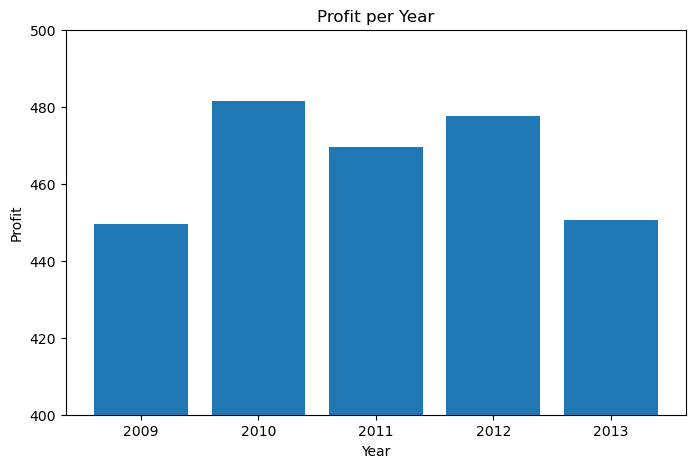

In [44]:
import pandas as pd

df = pd.DataFrame(profPerYear, columns=['YEAR', 'Profit'])

plt.figure(figsize=(8,5))
plt.title('Profit per Year')
plt.bar(df['Profit'], df['YEAR'])
plt.xticks(df['Profit'])
plt.ylim(400, 500)
plt.xlabel('Year')
plt.ylabel('Profit')
plt.show()



##### This analysis examines sales, customer behavior, employee performance, and geographic trends in the Chinook music store database.

##### The Rock genre is the primary revenue driver in the USA, significantly outperforming all other genres. Recent sales data indicates growing profitability of Pop and Blues albums, suggesting opportunities for targeted catalog expansion. Recommended additions include Instant Karma, The Cream Of Clapton, and Axé Bahia 2001.

##### Revenue is highly concentrated geographically. The USA and Canada generate the largest profits, with California as the top-performing U.S. state. In Europe, France, Germany, and the United Kingdom lead in total revenue, making them priority markets for future growth initiatives.

##### Employee performance is consistent across all sellers. Differences in total profit are explained primarily by tenure and customer volume rather than individual effectiveness. Experience level, age, and managerial structure show no measurable impact on sales results. Due to incomplete historical data, early-career performance cannot be reliably assessed.

##### Customer analysis shows no significant difference in average invoice value between private and corporate clients. Private customers generate higher total revenue due to transaction volume, not higher purchase value.

##### Overall revenue between 2009 and 2013 remains stable, indicating a mature business with limited organic growth. Future growth should focus on genre diversification, geographic expansion, and targeted marketing rather than internal operational changes.